# ML System Architectures: From a Model File to a Real Product

In M2 you trained a model that predicts who survives the Titanic. That was a big step. But here is an uncomfortable truth: a trained model, on its own, helps nobody. It is a file sitting on your laptop. No customer can use it, no app can call it, and nobody notices when it goes stale.

This notebook is about everything AROUND the model: the components that turn a model file into a working product, and how machine learning plugs into real tech architectures. We will not open the model's mathematical insides (that was M2 territory). Instead, we will build a small working version of every architectural component, on your laptop, using the same Titanic model you already know.

**What you will learn**

- What "architecture" means for ML systems: the components around the model and how they connect
- The two halves of every ML system: training (offline) and serving (online)
- The five core components: data pipeline, training pipeline, model registry, serving, monitoring
- The four serving patterns (batch, real-time API, streaming, embedded) and how to choose between them
- How to detect data drift, and why monitoring closes the loop back to training
- Where an ML service sits inside a normal product architecture
- When to build your own ML versus calling someone else's AI API

## How to run this notebook

- **Locally (Jupyter):** open this file in Jupyter (or VS Code) and run cells top to bottom.
- **Google Colab:** upload this notebook to [colab.research.google.com](https://colab.research.google.com) (or open it straight from GitHub) and run cells top to bottom.

The setup cell below installs any missing packages, so it works in both places. You do not need any account, API key, or cloud service to run this notebook - everything happens on the machine running the notebook. The only requirement is an internet connection to download the Titanic dataset.

Files created by this notebook (model files, prediction files) go into an `outputs/` folder next to the notebook.

In [1]:
# SETUP - run this cell first. It installs any missing packages.
# On Google Colab most packages are already installed, so this usually does nothing.
import importlib.util, subprocess, sys

def ensure(package, pip_name=None):
    if importlib.util.find_spec(package) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or package])

ensure("pandas"); ensure("numpy"); ensure("sklearn", "scikit-learn"); ensure("matplotlib"); ensure("scipy"); ensure("joblib")

## 1. What does "architecture" mean here?

First, a definition. **Architecture** = the components a system is made of, and how they are connected. Nothing more mysterious than that.

In M2 you produced two things:

- a **trained model**: in practice, just a file on disk (we saved it with `joblib`)
- a **predict function**: give it passenger data, get a survival prediction back

That is the whole model. Everything else that makes ML useful in the real world is architecture:

- **Data flowing in** - where does fresh data come from, who cleans it, where is it stored?
- **Training** - who retrains the model, how often, and what happens to the result?
- **Serving** - when an app needs a prediction, how does it get one?
- **Applications** - the websites, apps, and dashboards that actually use the predictions
- **Monitoring** - who notices when the model starts giving bad answers?

Here is the big picture. This diagram is the map for the whole notebook:

```
+--------------+    +---------------+    +-------------------+    +----------------+
| data sources |--->| data pipeline |--->| training pipeline |--->| model registry |
| (users, DBs, |    | collect,clean,|    | prep, fit,        |    | model files +  |
|  sensors...) |    | store         |    | evaluate          |    | version cards  |
+--------------+    +---------------+    +-------------------+    +----------------+
                                                  ^                        |
                                                  |                        v
                                                  |               +----------------+
                                        "retrain!"|               |    serving     |
                                                  |               | batch, API,    |
                                                  |               | stream, edge   |
                                                  |               +----------------+
                                                  |                        |
                                                  |                        v
                                          +---------------+       +----------------+
                                          |  monitoring   |<------|  applications  |
                                          | ops health +  |       | web, mobile,   |
                                          | data drift    |       | CRM, dashboards|
                                          +---------------+       +----------------+
```

Read it left to right: data comes in, a pipeline cleans it, a training pipeline turns it into model versions, a registry stores those versions, serving answers prediction requests, and applications consume the answers. Underneath, monitoring watches everything and, when the world changes, kicks the training pipeline back into action.

In the rest of this notebook we will build a small working version of every box in this diagram, using the Titanic model from M2. By the end, you will have simulated an entire ML system on your laptop.

## 2. The two halves of every ML system

Every ML system splits into two very different halves. Keep them apart in your head (and in your architecture):

- **TRAINING** (also called *offline*): learning from historical data to produce a model file.
- **INFERENCE** (also called *serving* or *online*): using that model file to answer predictions. **Inference** = asking a trained model for a prediction.

They could not be more different:

| | TRAINING | INFERENCE / SERVING |
|---|---|---|
| When does it run? | Occasionally (nightly, weekly, on demand) | Constantly, whenever someone needs a prediction |
| How heavy is it? | Heavy: crunches the full dataset, can take minutes to days | Light: one prediction takes milliseconds |
| Hardware | Big machines, sometimes GPUs | Small, cheap machines (or a phone) |
| Who triggers it? | A schedule, an engineer, or a monitoring alert | A user, an app, or an arriving event |
| Output | A model file (plus metrics) | A prediction (a number or a label) |
| If it fails | Annoying, but users do not notice - yesterday's model keeps serving | Users notice immediately |

**Why does separating them matter?** Imagine a user opens your app and the app says "please wait 20 minutes, we are retraining the model". Absurd - yet that is exactly what happens if you mix the two halves. The rule in every serious ML system: **you never retrain in front of a waiting user.** Training happens in the back room on its own schedule; serving uses the most recent finished model file. The bridge between the two halves is exactly that: a file. Train, save, load, serve.

## 3. Component 1 - the data pipeline

**Data pipeline** = an automated sequence of steps that moves data from where it is born to where it is useful: **collect -> clean -> store**.

This is literally your M1 skills (loading, cleaning, fixing missing values) made *repeatable*. In M1 you cleaned data by hand in a notebook. A company cannot re-run your notebook by hand every night at 3 AM - so the cleaning steps become **functions** that a machine can call on a schedule.

Where does the cleaned data end up? Two names you will hear constantly (names only for now):

- **Data warehouse** = a big database optimized for analysis, e.g. Google BigQuery.
- **Data lake** = cheap storage for raw files of any shape, e.g. Amazon S3.

The output of the data pipeline is the input of everything else. Bad data pipeline = bad model, no matter how clever the training. Hence the classic saying: *garbage in, garbage out*.

**WHAT:** we wrap the Titanic data preparation from M2 into a single function, `load_and_clean()`.

**WHY:** to make the point physically: *pipeline steps are functions, not manual notebook fiddling*. Once cleaning lives in a function, anything can call it - a scheduler at 3 AM, a training pipeline, or a test.

This is the exact same preparation you built step by step in M2 notebook `01-data-prep-and-feature-engineering` (Title from Name, FamilySize, IsAlone). Here it is compressed into one well-commented cell - revisit that notebook if any line looks unfamiliar.

In [2]:
import os
import numpy as np
import pandas as pd

DATA_URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

# The feature lists from M2 - we will reuse them all over this notebook.
NUMERIC_FEATURES = ["Age", "Fare", "SibSp", "Parch", "FamilySize"]
CATEGORICAL_FEATURES = ["Pclass", "Sex", "Embarked", "Title"]

def load_and_clean():
    """Data pipeline step: collect + clean. Same prep as M2 notebook 1."""
    # COLLECT: in real life this would query a database or data warehouse.
    df = pd.read_csv(DATA_URL)

    # CLEAN / ENGINEER (recap from M2):
    # 1) Title, extracted from Name ("Braund, Mr. Owen Harris" -> "Mr"),
    #    grouped into Mr / Mrs / Miss / Master / Rare.
    df["Title"] = df["Name"].str.extract(r" ([A-Za-z]+)\.", expand=False)
    df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    df.loc[~df["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Title"] = "Rare"

    # 2) FamilySize = siblings/spouses + parents/children + the passenger.
    df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

    # 3) IsAlone = 1 if the passenger travels with no family.
    df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

    # STORE: in real life we would write df to a warehouse table here.
    return df

data = load_and_clean()
print("Pipeline output:", len(data), "rows,", len(data.columns), "columns")
data[["Name", "Title", "FamilySize", "IsAlone", "Survived"]].head()

Pipeline output: 891 rows, 15 columns


,Name,Title,FamilySize,IsAlone,Survived
0,"Braund, Mr. Owen Harris",Mr,2,0,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,1
2,"Heikkinen, Miss. Laina",Miss,1,1,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,1
4,"Allen, Mr. William Henry",Mr,1,1,0


## 4. Component 2 - the training pipeline

**Training pipeline** = the whole journey from clean data to an evaluated model, written as one repeatable script: prep -> split -> fit -> evaluate -> hand over the result.

In M2 you did those steps as separate notebook cells, clicking Run on each one. That is perfect for *learning* and *exploring*. It is terrible for *operating*: nobody wants to be the person who must click the right cells in the right order every Sunday night. So, exactly like the data pipeline, training becomes a **function**.

**WHAT:** we write `train_pipeline(data)` which does the full M2 workflow in one call: build the preprocessing (impute + scale numbers, impute + one-hot encode categories), split the data, fit a RandomForest, evaluate on the held-out test set, and return `(model, metrics)`.

**WHY:** one callable = one button any machine can press. The returned `metrics` dictionary is just as important as the model - the next component (the registry) will store it so we always know how good each model version was.

In [3]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def train_pipeline(data, n_estimators=100, max_depth=8):
    """Full training pipeline: prep -> split -> fit -> evaluate.

    Returns (model, metrics). The model is a sklearn Pipeline, so the
    preprocessing travels INSIDE the saved model - a lesson from M2."""
    X = data[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    y = data["Survived"]

    # PREP: same ColumnTransformer as M2.
    preprocess = ColumnTransformer([
        ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                          ("scale", StandardScaler())]), NUMERIC_FEATURES),
        ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                          ("encode", OneHotEncoder(handle_unknown="ignore"))]),
         CATEGORICAL_FEATURES),
    ])
    model = Pipeline([
        ("preprocess", preprocess),
        ("classifier", RandomForestClassifier(
            n_estimators=n_estimators, max_depth=max_depth, random_state=42)),
    ])

    # SPLIT -> FIT -> EVALUATE
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    model.fit(X_train, y_train)
    predicted = model.predict(X_test)

    metrics = {
        "test_accuracy": round(accuracy_score(y_test, predicted), 4),
        "test_f1": round(f1_score(y_test, predicted), 4),
        "n_train_rows": len(X_train),
        "n_test_rows": len(X_test),
        "params": {"n_estimators": n_estimators, "max_depth": max_depth},
    }
    return model, metrics

model_v1, metrics_v1 = train_pipeline(data)
metrics_v1

{'test_accuracy': 0.8324,
 'test_f1': 0.7619,
 'n_train_rows': 712,
 'n_test_rows': 179,
 'params': {'n_estimators': 100, 'max_depth': 8}}

**Who presses the button?** In real companies, usually nobody - a **scheduler** does. A scheduler is a program whose only job is to run other programs at set times. Many companies retrain nightly or weekly: the scheduler simply calls a function like our `train_pipeline` at 02:00 and walks away. Names you will meet (one line each, that is all you need for now):

- **cron** - the classic Unix scheduler: "run this command every day at 02:00".
- **Apache Airflow** - an open-source tool for scheduling multi-step pipelines with dependencies.
- **Vertex AI Pipelines** - Google Cloud's managed service for running ML pipelines.
- **SageMaker Pipelines** - the AWS equivalent.

The tool changes, the idea never does: *training is a scheduled function call, not a person clicking cells.*

## 5. Component 3 - the model registry

If training runs every week, you soon have a pile of model files. Now the awkward questions start:

- Which model is live in production *right now*?
- What was its test score? On which data was it trained?
- The new model behaves strangely - **can we roll back** to last week's version?

A folder full of files named `model_final_v2_REALLY_FINAL.joblib` cannot answer any of these. A **model registry** can.

**Model registry** = a catalog of model versions where each version stores the model file PLUS a "model card" of facts about it: version number, creation date, evaluation scores, which features it expects. Think of it as *git for models*, in spirit: numbered versions you can list, load, compare, and roll back to.

**WHAT:** we build a tiny but honest registry on disk. Each version gets its own folder under `outputs/registry/` containing two files:

```
outputs/registry/
    v001/
        model.joblib     <- the trained model (preprocessing included)
        card.json        <- the facts: version, date, scores, features
    v002/
        ...
```

**WHY:** with this structure, "which model is live?" becomes "read the folder". We then register the model we just trained as `v001`.

(We clear the registry folder first so this notebook always starts fresh and gives the same result every run.)

In [4]:
import json
import shutil
import joblib
from datetime import datetime, timezone

REGISTRY_DIR = os.path.join("outputs", "registry")
shutil.rmtree(REGISTRY_DIR, ignore_errors=True)   # fresh demo registry every run
os.makedirs(REGISTRY_DIR, exist_ok=True)

def register_model(model, metrics, features):
    """Store a model + its card under the next free version number."""
    existing = sorted(d for d in os.listdir(REGISTRY_DIR) if d.startswith("v"))
    version = f"v{len(existing) + 1:03d}"
    version_dir = os.path.join(REGISTRY_DIR, version)
    os.makedirs(version_dir, exist_ok=True)

    # File 1: the model itself.
    joblib.dump(model, os.path.join(version_dir, "model.joblib"))

    # File 2: the model card - the facts we will need later.
    card = {
        "version": version,
        "created_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "test_accuracy": metrics["test_accuracy"],
        "test_f1": metrics["test_f1"],
        "params": metrics["params"],
        "features": features,
    }
    with open(os.path.join(version_dir, "card.json"), "w") as f:
        json.dump(card, f, indent=2)

    print(f"Registered {version}  (test accuracy {card['test_accuracy']})")
    return version

register_model(model_v1, metrics_v1, NUMERIC_FEATURES + CATEGORICAL_FEATURES)

Registered v001  (test accuracy 0.8324)


'v001'

**WHAT:** we train a *second* model version with different settings (300 trees instead of 100) and register it too.

**WHY:** a registry only earns its keep once there are at least two versions to compare. This simulates what happens in real life every retraining cycle: new training run -> new candidate version, sitting next to the old one.

In [5]:
# A new training run with a different setting -> a new candidate version.
model_v2, metrics_v2 = train_pipeline(data, n_estimators=300, max_depth=8)
register_model(model_v2, metrics_v2, NUMERIC_FEATURES + CATEGORICAL_FEATURES)

Registered v002  (test accuracy 0.8212)


'v002'

**WHAT:** two reading tools for the registry:

1. `load_model(version=None)` - loads a specific version, or the *latest* one when no version is given. This is the function serving will use.
2. `registry_table()` - loops over all `card.json` files and shows them as one tidy DataFrame.

**WHY:** these two functions answer the awkward questions from before. "Which model is live?" -> `load_model()` returns the latest. "Can we roll back?" -> `load_model("v001")`. "What were the scores?" -> `registry_table()`.

In [6]:
def load_model(version=None):
    """Load a model from the registry. version=None means 'the latest'."""
    versions = sorted(d for d in os.listdir(REGISTRY_DIR) if d.startswith("v"))
    if not versions:
        raise FileNotFoundError("The registry is empty - train and register a model first.")
    if version is None:
        version = versions[-1]                     # 'v002' sorts after 'v001'
    model = joblib.load(os.path.join(REGISTRY_DIR, version, "model.joblib"))
    with open(os.path.join(REGISTRY_DIR, version, "card.json")) as f:
        card = json.load(f)
    return model, card

def registry_table():
    """One row per registered version, built from the card.json files."""
    rows = []
    for version in sorted(os.listdir(REGISTRY_DIR)):
        card_path = os.path.join(REGISTRY_DIR, version, "card.json")
        if os.path.exists(card_path):
            with open(card_path) as f:
                card = json.load(f)
            rows.append({
                "version": card["version"],
                "created_at": card["created_at"],
                "test_accuracy": card["test_accuracy"],
                "test_f1": card["test_f1"],
                "n_estimators": card["params"]["n_estimators"],
                "max_depth": card["params"]["max_depth"],
            })
    return pd.DataFrame(rows)

live_model, live_card = load_model()               # no argument -> latest version
print("Serving would use:", live_card["version"])

rollback_model, rollback_card = load_model("v001") # rolling back is just as easy
print("Roll back target :", rollback_card["version"])

registry_table()

Serving would use: v002
Roll back target : v001


,version,created_at,test_accuracy,test_f1,n_estimators,max_depth
0,v001,2026-09-06T15:28:51+00:00,0.8324,0.7619,100,8
1,v002,2026-09-06T15:28:51+00:00,0.8212,0.7460,300,8


Our folder-based registry is real enough to teach the concept, and honestly, not far from what small teams actually run. The grown-up versions add a web interface, access control, and "staging vs production" labels:

- **MLflow Model Registry** - the most popular open-source option.
- **Vertex AI Model Registry** (Google Cloud) and **SageMaker Model Registry** (AWS) - the managed cloud equivalents.

Same idea in all of them: versioned models with cards, a "latest/production" pointer, and easy rollback.

## 6. Component 4 - serving: the four patterns

**Serving** = getting predictions from the model to whoever needs them. This is the heart of the notebook, because it is the architectural decision you will face most often in practice.

There are four classic patterns. All four use the *same* trained model - what changes is **when** the prediction is computed and **how** it travels to the application:

1. **Batch** - predict everything ahead of time, on a schedule; apps read stored results.
2. **Real-time API** - predict on demand, one request at a time, over the network.
3. **Streaming** - predict on each event as it flows through the system.
4. **Embedded / edge** - the model ships inside the app or device itself.

We take them one by one, then compare them all in one decision table.

### 6.1 Batch scoring

**Batch scoring** = a scheduled job scores a whole group of records in one go, stores the results, and applications simply *read* the stored results. The classic example: a telecom computes a churn score (how likely is this customer to leave?) for all 5 million customers every night; the next morning, support agents see the scores in their CRM.

The trick that makes batch beautiful: **the app never waits for the model.** By the time anyone asks, the answer is already sitting in a database or file. The price: predictions can be up to a day old, and you cannot score something the model has never seen (a brand-new customer has no row yet).

**WHAT:** we simulate the nightly job. `nightly_batch_job()` loads the latest model from our registry, scores *every* passenger in one go, and writes `outputs/batch/predictions_<date>.csv` with the passenger id, survival probability, timestamp, and model version.

**WHY:** this is the complete batch pattern in miniature - schedule (pretend it is 03:00), score all, store with enough metadata to trace every number back to the model that produced it.

In [7]:
from datetime import date

BATCH_DIR = os.path.join("outputs", "batch")
shutil.rmtree(BATCH_DIR, ignore_errors=True)      # fresh demo folder every run
os.makedirs(BATCH_DIR, exist_ok=True)

def nightly_batch_job():
    """Pretend it is 03:00 and nobody is awake. Score everyone, store results."""
    model, card = load_model()                    # always the latest registered model
    passengers = load_and_clean()                 # in real life: yesterday's fresh data
    X = passengers[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

    scores = pd.DataFrame({
        "PassengerId": passengers["PassengerId"],
        "survival_probability": model.predict_proba(X)[:, 1].round(4),
        "scored_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),
        "model_version": card["version"],
    })
    out_path = os.path.join(BATCH_DIR, f"predictions_{date.today().isoformat()}.csv")
    scores.to_csv(out_path, index=False)
    return out_path, scores

batch_path, batch_scores = nightly_batch_job()
print(f"Nightly job wrote {len(batch_scores)} predictions to {batch_path}")
batch_scores.head()

Nightly job wrote 891 predictions to outputs/batch/predictions_2026-09-06.csv


,PassengerId,survival_probability,scored_at,model_version
0,1,0.1132,2026-09-06T15:28:51+00:00,v002
1,2,0.9996,2026-09-06T15:28:51+00:00,v002
2,3,0.4299,2026-09-06T15:28:51+00:00,v002
3,4,0.9972,2026-09-06T15:28:51+00:00,v002
4,5,0.1325,2026-09-06T15:28:51+00:00,v002


**WHAT:** now we play the *application* side. At 09:00 a user opens the app and asks about passenger 42. The app just reads one row from the stored file - no model in sight - and we time how long that takes.

**WHY:** to feel the payoff of the batch pattern: the answer is instant, because the expensive work happened hours ago. The model could even be down right now and the app would not care.

In [8]:
import time

def app_get_prediction(passenger_id):
    """What the app does: read a stored number. No model involved."""
    scores = pd.read_csv(batch_path)
    row = scores.loc[scores["PassengerId"] == passenger_id].iloc[0]
    return row["survival_probability"], row["model_version"]

start = time.perf_counter()
probability, used_version = app_get_prediction(42)
elapsed_ms = (time.perf_counter() - start) * 1000

print(f"Passenger 42 -> survival probability {probability} (scored by model {used_version})")
print(f"Answered in {elapsed_ms:.1f} ms. The app never waited for the model.")

Passenger 42 -> survival probability 0.6306 (scored by model v002)
Answered in 13.3 ms. The app never waited for the model.


### 6.2 Real-time API

Batch fails you the moment the input did not exist last night. A user just typed brand-new data into a form - there is no precomputed row for that. You need a prediction *now*, from *fresh* input.

**Real-time API serving** = the model runs inside a small always-on service, reachable at an HTTP URL. An **API** (Application Programming Interface) here means: a web address that programs, rather than people, talk to. The app sends the input data, the service runs `predict`, the answer comes back in milliseconds. The shape of it, in pseudocode:

```
service starts -> model = load_model()          # once, at startup
on POST /predict with passenger data:
    probability = model.predict_proba(data)
    return {"survival_probability": probability}
```

That is the entire idea. We keep it short here on purpose: **notebook 2 of this module (`02-deploying-models-in-the-cloud`) builds this pattern for real** - a FastAPI prediction service, packed into a Docker container, deployed to Google Cloud Run and AWS App Runner, reachable from anywhere on the internet. Everything you built in this notebook (registry included) feeds straight into it.

### 6.3 Streaming

Some inputs do not wait for anyone to ask. Card payments, sensor readings, clicks - they arrive as a continuous river of **events** (an event = one thing that happened, as a small message). Fraud detection is the classic case: every single payment must be checked *as it happens*; batch would be hours too late, and nobody is manually calling an API per payment - the events themselves trigger the predictions.

**Streaming serving** = the model sits on the event river and scores each event as it flows past:

```
[payment] --> [event stream] --> [model scores each event] --> [decision]
[payment] -->  (e.g. Kafka)  -->  fraud probability: 0.02  --> [approve]
[payment] -->                -->  fraud probability: 0.97  --> [block + alert]
```

The plumbing that carries the river is a tool like **Apache Kafka** (a system for passing streams of events between services - name only for now).

**WHAT:** an honest toy of streaming: a loop over 5 "arriving" passenger events. Each event is scored *the moment it arrives*, with a timestamp print, and a short pause before the next one arrives.

**WHY:** to feel the difference with batch. Batch scored 891 rows in one gulp at 03:00; streaming scores one row at a time, all day long, the moment each event shows up.

In [9]:
# Five passengers "arriving" one by one, like payments hitting a card network.
passengers = load_and_clean()
event_ids = passengers.sample(5, random_state=42).index

stream_model, stream_card = load_model()
print(f"Stream scorer online (model {stream_card['version']}). Waiting for events...\n")

for idx in event_ids:
    # One event arrives: a single-row DataFrame (dtypes preserved).
    event = passengers.loc[[idx], NUMERIC_FEATURES + CATEGORICAL_FEATURES]
    probability = stream_model.predict_proba(event)[0, 1]
    stamp = datetime.now().strftime("%H:%M:%S.%f")[:-3]
    pid = int(passengers.loc[idx, "PassengerId"])
    print(f"[{stamp}] event in: passenger {pid:>3}  ->  score {probability:.3f}")
    time.sleep(0.3)                                # pretend we wait for the next event

Stream scorer online (model v002). Waiting for events...

[17:28:51.848] event in: passenger 710  ->  score 0.767


[17:28:52.166] event in: passenger 440  ->  score 0.127


[17:28:52.504] event in: passenger 841  ->  score 0.131


[17:28:52.840] event in: passenger 721  ->  score 0.976


[17:28:53.162] event in: passenger  40  ->  score 0.458


### 6.4 Embedded / edge

The fourth pattern removes the network entirely. **Embedded (or edge) serving** = the model file ships *inside* the application or device, and predictions run right there. Your phone unlocking with your face, a browser translating a page offline, a tractor detecting weeds in a field without coverage - all embedded.

Why choose it:

- **No network needed** - works offline, no latency from a round trip.
- **Privacy** - the data (your face!) never leaves the device.
- **Cost** - no servers to pay for; every user brings their own hardware.

The trade-offs are just as clear:

- **Updating is hard** - a new model version means shipping a new app version through app stores and waiting for users to update. Compare that with a real-time API, where you swap the model once on the server and every user instantly gets the new version.
- **Limited hardware** - the model must be small and battery-friendly, so heavyweight models need shrinking first.
- **Your model leaves home** - it is on the user's device, where a determined person can extract and inspect it.

### 6.5 The decision table

If you remember one artifact from this notebook, make it this table. It is how architects actually choose a serving pattern:

| | **Batch** | **Real-time API** | **Streaming** | **Embedded / edge** |
|---|---|---|---|---|
| When is the prediction made? | On a schedule, ahead of time | The moment an app asks | The moment an event arrives | The moment the device needs it |
| Freshness of input | Hours to a day old | Brand new (user just typed it) | Seconds old (events in flight) | Brand new, on-device |
| Latency the consumer sees | Instant (just a read) | ~10-500 ms (network + predict) | Milliseconds per event | Instant, no network |
| Cost profile | Cheap: one big job per day | A server running 24/7 | Stream infrastructure running 24/7 | Near zero: users' hardware |
| Typical example | Nightly churn scores in a CRM | Price estimate as user fills a form | Fraud check on each card payment | Face unlock on a phone |
| Fails when... | Input did not exist last night | Network is down or slow | You do not really have event streams | Model too big / needs frequent updates |

**Rule of thumb** - ask two questions in order:

1. *Can I compute the answers ahead of time?* If yes -> **batch**. It is the cheapest and simplest; always check this first.
2. If not, *what triggers the prediction?* A user or app asking -> **real-time API**. Events flowing by themselves -> **streaming**. The device itself, possibly offline -> **embedded**.

Real systems mix patterns freely: Netflix computes your recommendations in batch overnight, but ranks them in real time when you open the app.

## 7. Component 5 - monitoring and the feedback loop

You shipped a model. Congratulations - now the real job starts: **watching it**. There are two very different kinds of watching:

- **Ops health** - is the service up? How slow are responses? What is the error rate? This is the same monitoring as for any web service, nothing ML-specific about it.
- **ML health** - is the *world* still like the training data? The service can be perfectly "up" while quietly giving worse and worse answers. This one is ML-specific, and it is the sneaky one.

The main villain of ML health is **data drift** = the incoming data slowly (or suddenly) stops resembling the data the model was trained on.

A story to make it concrete. Our model learned from passengers of 1912: certain ages, certain fares, "women and children first". Now imagine we naively point it at passengers boarding a 2020 cruise ship: everyone is older (people live longer), fares are wildly different (a century of inflation), and the whole social context changed. The model still runs. It still outputs confident probabilities. **No error is raised anywhere.** The answers are just... quietly wrong. That is drift: the model did not break - the world moved.

Since no exception will ever fire, the only defense is to *measure* the difference between training-era data and incoming data. Let us build exactly that.

**WHAT:** we manufacture drift on purpose. `reference_df` is the data our model was trained on. `new_df` simulates "new incoming passengers": the same people but 15 years older, paying twice the fare (a century of inflation, compressed).

**WHY:** in real life you never get to *see* drift this cleanly - you have to detect it in the numbers. By constructing it ourselves, we know exactly what our detector *should* find: Age and Fare drifted, everything else did not.

In [10]:
# The world our model knows: the training-era data.
reference_df = load_and_clean()

# The world as it looks today: same schema, shifted reality.
new_df = reference_df.copy()
new_df.loc[:, "Age"] = new_df["Age"] + 15        # passengers got older
new_df.loc[:, "Fare"] = new_df["Fare"] * 2       # a century of inflation

print("Mean Age  - training era:", round(reference_df["Age"].mean(), 1),
      "| new passengers:", round(new_df["Age"].mean(), 1))
print("Mean Fare - training era:", round(reference_df["Fare"].mean(), 1),
      "| new passengers:", round(new_df["Fare"].mean(), 1))

Mean Age  - training era: 29.7 | new passengers: 44.7
Mean Fare - training era: 32.2 | new passengers: 64.4


**WHAT:** `drift_report(reference_df, new_df)` loops over the numeric features and, for each one, compares mean and standard deviation, then runs the **Kolmogorov-Smirnov test** (`scipy.stats.ks_2samp`) - in one sentence: a score for how different two distributions are, where a very small p-value means "these two samples do not look like they come from the same world". Each feature gets a DRIFT or OK flag.

**WHY:** this is the core of every real drift monitor (commercial tools do exactly this, feature by feature, on a schedule). Note what it does NOT need: the true answers. We are not checking whether predictions were right - only whether the incoming data still looks like home.

In [11]:
from scipy import stats

def drift_report(reference_df, new_df, features=None, alpha=0.05):
    """Compare each numeric feature between training-era and new data.

    alpha: if the KS test p-value drops below this, we flag DRIFT."""
    features = features if features is not None else NUMERIC_FEATURES
    rows = []
    for feature in features:
        old = reference_df[feature].dropna()
        new = new_df[feature].dropna()
        ks_stat, p_value = stats.ks_2samp(old, new)
        rows.append({
            "feature": feature,
            "mean_before": round(old.mean(), 2),
            "mean_now": round(new.mean(), 2),
            "std_before": round(old.std(), 2),
            "std_now": round(new.std(), 2),
            "ks_pvalue": round(p_value, 4),
            "status": "DRIFT" if p_value < alpha else "OK",
        })
    return pd.DataFrame(rows)

drift_report(reference_df, new_df)

,feature,mean_before,mean_now,std_before,std_now,ks_pvalue,status
0,Age,29.70,44.70,14.53,14.53,0.0,DRIFT
1,Fare,32.20,64.41,49.69,99.39,0.0,DRIFT
2,SibSp,0.52,0.52,1.10,1.10,1.0,OK
3,Parch,0.38,0.38,0.81,0.81,1.0,OK
4,FamilySize,1.90,1.90,1.61,1.61,1.0,OK


Exactly as constructed: Age and Fare scream DRIFT, while SibSp, Parch and FamilySize (which we did not touch) come back OK. The monitor found the two changed features and did not cry wolf on the others.

**WHAT:** now let us *see* one drifted feature - Age before vs after, side by side.

**WHY:** a histogram is how you would double-check an alert in practice. Tables raise the flag; a picture tells you what actually happened to the data.

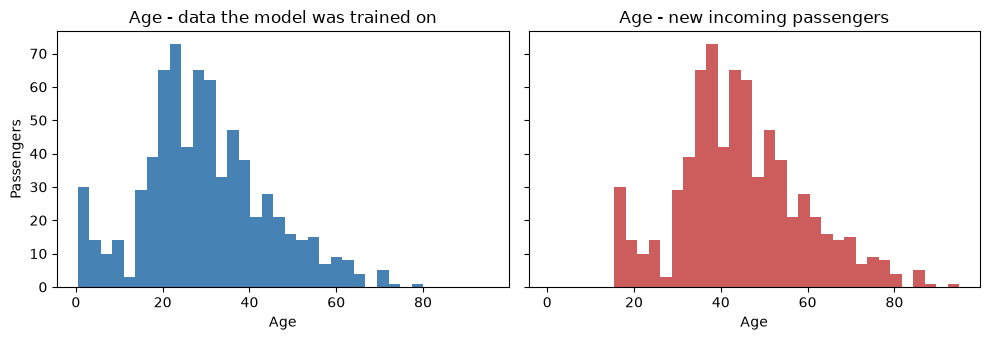

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharex=True, sharey=True)
axes[0].hist(reference_df["Age"].dropna(), bins=30, color="steelblue")
axes[0].set_title("Age - data the model was trained on")
axes[1].hist(new_df["Age"].dropna(), bins=30, color="indianred")
axes[1].set_title("Age - new incoming passengers")
for ax in axes:
    ax.set_xlabel("Age")
axes[0].set_ylabel("Passengers")
plt.tight_layout()
plt.show()

**Closing the loop.** Look back at the big diagram in section 1 - monitoring is the box that points *back* to the training pipeline, and now you can see the whole cycle spin:

```
monitoring detects drift ("Age and Fare moved!")
        -> triggers the training pipeline on fresh data     (section 4)
        -> which registers a new version in the registry    (section 5)
        -> which serving picks up via load_model()          (section 6)
        -> which monitoring starts watching again           (section 7)
```

No human in the middle is strictly required: drift alert -> retrain -> register -> serve is exactly the loop mature ML teams automate. You have now built - by hand, on a laptop - every single box of the architecture diagram this notebook opened with.

## 8. Where ML sits in a product architecture

Zoom out. Most software you use every day is some variation of the classic three-piece web architecture:

```
[browser / mobile app] <----> [backend] <----> [database]
      the frontend            the logic         the data
```

Where does ML go? As **one more component that the backend calls** - a separate little service with the model inside:

```
[browser / mobile app] <----> [backend] <----> [database]
                                  |
                                  | "what is the survival probability for this passenger?"
                                  v
                          [ML service (model)]
```

Notice what the diagram does NOT show: an arrow from the browser straight to the ML service. **The frontend never calls the model service directly**, for three reasons:

- **Secrets** - calling the ML service may need credentials; anything in a browser can be read by the user, so secrets cannot live there.
- **Validation** - the backend checks and cleans the input first; a browser request can contain anything.
- **Control** - the backend can log, rate-limit, cache, or swap the ML service without any change to the app users have installed.

(Notebook 3 of this module covers the calling details - how application code talks to a prediction API properly.)

**Why keep the ML service separate** instead of stuffing the model inside the backend? The same reasons any component gets its own service: it can **scale independently** (predictions may need more machines than the rest of the app, or fewer), it can **deploy independently** (ship a new model version without redeploying the whole product), and it can be **owned by a different team** (the data team ships models; the product team ships features; neither blocks the other).

## 9. Build vs buy

You need ML in your product. That does not automatically mean *training* a model. There are three ways to get the intelligence into your architecture:

1. **Train and host your own** - the path of M2 and M3: your data, your training pipeline, your serving. Full control and privacy; requires data, skills, and maintenance (the whole loop you just built).
2. **Call a third-party AI API** - someone else trained and hosts the model; you send input over HTTP and pay per call. Examples: OpenAI (text), Google Cloud Vision (images). Fastest possible start, world-class quality - but your data leaves your house, and the per-call bills grow with usage.
3. **AutoML platforms** - the in-between: you bring your own data, the platform automates training and hosting (Google Vertex AI AutoML, Azure ML). More control than option 2, less skill needed than option 1.

| Question to ask | Points toward BUILD (1) | Points toward BUY (2) |
|---|---|---|
| Is the problem unique to us? | Yes - nobody sells a "predict OUR churn" API | No - it is generic (translate text, read receipts) |
| Is the data sensitive? | Yes - it should not leave our systems | No - sending it out is acceptable |
| Do we have data + ML skills? | Yes - and the volume to use them | No - and we need results this quarter |
| Budget shape? | Fixed team cost, low per-prediction cost | Zero upfront, pay per call forever |

The architectural punchline: **to your backend, options 1 and 2 look identical.** Either way, the backend calls a prediction API over HTTP - the only difference is whether the URL points at your own ML service or at someone else's. The architecture diagram from section 8 does not change at all.

## 10. Three reference architectures

Three real-world cases, one per serving pattern family. For each: the diagram, the pattern choice and why, and one sentence on monitoring.

### Case A - telco churn prediction (BATCH)

```
[billing + usage data] -> [data pipeline] -> [nightly job: score all 5M customers]
                                                        |
                                                        v
                                       [churn_scores table in the CRM database]
                                                        ^
                                                        | instant read
                                     [CRM screen used by support agents]
```

- **Pattern: batch.** Churn risk changes slowly - a score from last night is plenty fresh, and scoring 5 million customers in one nightly job is far cheaper than keeping an always-on prediction service.
- **Monitoring:** compare this month's usage-data distributions against the training data monthly - drift here (new tariff plans, new usage habits) is the main reason churn models rot.

### Case B - bank card fraud detection (STREAMING / REAL-TIME)

```
[card payment] -> [event stream (Kafka)] -> [fraud model scores the event]
                                                   |            (< 100 ms)
                                     +-------------+-------------+
                                     v                           v
                              [score < 0.9]                [score >= 0.9]
                              [approve payment]            [block + alert customer]
```

- **Pattern: streaming.** Milliseconds matter - the decision must happen *between* the card swipe and the "approved" beep, and payments arrive as a nonstop river of events, not as user requests. Batch would detect fraud hours after the money left.
- **Monitoring:** fraudsters adapt on purpose (this is drift with an adversary behind it), so score distributions and fraud-catch rates are watched daily and the model is retrained frequently.

### Case C - photo app background blur (EMBEDDED, cloud fallback)

```
[phone camera] -> [model inside the app: blur the background]   <- no network needed
                          |
                          | only for huge images / old phones
                          v
                  [cloud API fallback]
```

- **Pattern: embedded.** Photos are private (they should not leave the phone), the effect must work offline and feel instant - so the model ships inside the app, with a cloud API as fallback for devices too weak to run it.
- **Monitoring:** on-device telemetry reports crash rates and how often the fallback triggers; model quality issues show up as user complaints and edit-undo rates rather than server metrics.

## 11. MLOps in one breath

There is a name for everything you did by hand today: **MLOps** = DevOps ideas applied to ML systems. In one breath:

- **Version everything** - code (git), data (snapshots), and models (the registry you built).
- **Test pipelines** - the data pipeline and training pipeline are functions, so they can have automated tests like any other code.
- **Automate the loop** - drift alert -> retrain -> register -> serve, without a human pressing buttons.

Tools you will meet in job descriptions (one line each, names only):

- **MLflow** - open-source experiment tracking and model registry.
- **Apache Airflow** - general-purpose pipeline scheduler.
- **Kubeflow** - ML pipelines on Kubernetes.
- **Vertex AI Pipelines** - Google Cloud's managed ML pipeline service.
- **SageMaker Pipelines** - the AWS equivalent.

Every one of these is a polished, scaled-up version of a function or folder you wrote in this notebook. If you understood today's toy system, the tools will feel familiar.

## 12. Bridge to the rest of M3

Here is the module map - the same architecture, with the next two notebooks placed on it:

```
                                                       THIS NOTEBOOK (simulated it all)
  ................................................................................
  :                                                                              :
  [data] --> [training pipeline] --> [model registry] --> [API service] --> [applications]
  :                                                            |                 |
  :................[ monitoring watches everything ]...........|.................|
                                                               |                 |
                                             NOTEBOOK 2:       |   NOTEBOOK 3:   |
                                             FastAPI + Docker  |   consuming the |
                                             + Cloud Run /     |   API from apps |
                                             AWS App Runner    |                 |
```

You have now simulated every box on a laptop. The next two notebooks make the two rightmost boxes real: **notebook 2** takes a trained model exactly like the one in your registry and turns it into a genuine HTTP prediction service in the cloud (FastAPI, Docker, Google Cloud Run, AWS App Runner); **notebook 3** sits on the application side and consumes that service properly. Same Titanic model, all the way to production.

## 13. Key takeaways

- A trained model is just a file plus a predict function. **Architecture is everything around it**: data in, training, registry, serving, applications, monitoring.
- Every ML system has **two halves**: training (offline, occasional, heavy) and serving (online, constant, light). Never retrain in front of a waiting user - the bridge between the halves is a model file.
- **Pipeline steps are functions, not manual notebook fiddling.** `load_and_clean()` and `train_pipeline()` are what schedulers call at 3 AM.
- A **model registry** answers the questions a folder of files cannot: which model is live, how good is it, can we roll back. Version + card, every time.
- There are **four serving patterns** - batch, real-time API, streaming, embedded. Ask "can I precompute?" first, then "what triggers the prediction?". The decision table in section 6.5 is your cheat sheet.
- Models fail silently through **data drift**: the service stays up while the world moves away from the training data. Monitor input distributions (KS test per feature); drift closes the loop back to training.
- In a product, the ML model lives in a **separate service that the backend calls** - the frontend never talks to it directly.
- **Build vs buy** changes who trains and hosts the model, but to your backend both look like calling an API.

## 14. Practice exercises

**Exercise 1 - pick the serving pattern.** For each scenario, pick ONE of the four serving patterns (batch, real-time API, streaming, embedded) and justify your choice in one or two sentences using the decision table:

a) A supermarket chain wants demand forecasts per product per store to plan tomorrow's deliveries. Forecasts are used by planners every morning.
b) A dating app wants to suggest an opening message the instant a user opens a chat window, based on both profiles.
c) A wind farm operator wants to flag failing turbines from vibration sensor readings that arrive every second.
d) A note-taking app wants handwriting recognition that also works in airplane mode.

**Exercise 2 - a third model version.** Using `train_pipeline` and `register_model`, train a model with a different setting (for example `max_depth=12`), register it as v003, and show that `registry_table()` now lists three versions. Then check what `load_model()` (no arguments) returns now.

**Exercise 3 - drift for categories.** `drift_report` only checks numeric features. Extend it to also flag a *categorical* feature by comparing category frequencies: compute each category's share in the reference data and in the new data (`value_counts(normalize=True)`), and flag DRIFT if any category's share moved by more than 10 percentage points. Test it on a copy of `new_df` where you change some `Embarked` values.

**Exercise 4 - architecture on paper.** A study app wants a feature that predicts "will this student pass the course?" from their activity (logins, exercises done, quiz scores). Sketch the architecture *in words*: where does the data come from, when does training run, which serving pattern would you choose (and why), and what would you monitor? No code - just the boxes and arrows in sentences.

## 15. Solutions

### Solution 1 - pick the serving pattern

a) **Batch.** The answers can be computed ahead of time (tonight, for tomorrow), planners read them in the morning, and nothing about the input appears at the last second. Cheapest pattern wins.

b) **Real-time API.** The input (which two profiles just opened a chat) only exists the moment the user acts, and a person is actively waiting - so a backend calls the prediction service on demand.

c) **Streaming.** Sensor readings are a continuous river of events arriving on their own, and a failing turbine must be flagged within seconds - the events themselves trigger the scoring.

d) **Embedded.** "Works in airplane mode" rules out every network pattern; the recognition model must ship inside the app and run on the device.

### Solution 2 - a third model version

**WHAT:** one more run of the training pipeline with `max_depth=12`, registered as v003; then we list the registry and reload the latest model.

**WHY:** to rehearse the full registry cycle once more - and to notice that `load_model()` with no arguments *automatically* serves v003 now. Serving code never changed; it always follows the latest version.

In [13]:
# Train with a different setting and register - that is the whole exercise.
model_v3, metrics_v3 = train_pipeline(data, n_estimators=100, max_depth=12)
register_model(model_v3, metrics_v3, NUMERIC_FEATURES + CATEGORICAL_FEATURES)

# The registry now lists three versions...
display(registry_table())

# ...and "latest" has moved forward without touching any serving code.
_, latest_card = load_model()
print("load_model() now returns:", latest_card["version"])

Registered v003  (test accuracy 0.8045)


,version,created_at,test_accuracy,test_f1,n_estimators,max_depth
0,v001,2026-09-06T15:28:51+00:00,0.8324,0.7619,100,8
1,v002,2026-09-06T15:28:51+00:00,0.8212,0.7460,300,8
2,v003,2026-09-06T15:28:54+00:00,0.8045,0.7368,100,12


load_model() now returns: v003


### Solution 3 - drift for categories

**WHAT:** `drift_report_v2` keeps the numeric checks and adds categorical ones: for each categorical feature it compares category shares between reference and new data, flagging DRIFT when any single category's share moved by more than 10 percentage points. We test it on a copy of `new_df` where roughly 40 percent of passengers suddenly embarked at "C".

**WHY:** the KS test needs numbers, so categories need their own comparison - share-per-category is the simplest honest one. Note that `Sex` and `Pclass` come back OK (we never touched them) while `Embarked` gets flagged.

In [14]:
def drift_report_v2(reference_df, new_df, numeric=None, categorical=None,
                    alpha=0.05, max_share_shift=0.10):
    """Numeric drift (KS test) + categorical drift (share-per-category shift)."""
    numeric = numeric if numeric is not None else NUMERIC_FEATURES
    categorical = categorical if categorical is not None else ["Pclass", "Sex", "Embarked"]

    # Part 1: the numeric report we already have.
    report = drift_report(reference_df, new_df, features=numeric, alpha=alpha)
    report = report[["feature", "ks_pvalue", "status"]].copy()
    report.loc[:, "type"] = "numeric"
    report.loc[:, "max_share_shift"] = np.nan

    # Part 2: categorical features - compare each category's share.
    rows = []
    for feature in categorical:
        old_share = reference_df[feature].value_counts(normalize=True)
        new_share = new_df[feature].value_counts(normalize=True)
        # Biggest absolute move of any single category's share:
        shift = old_share.sub(new_share, fill_value=0).abs().max()
        rows.append({
            "feature": feature, "ks_pvalue": np.nan,
            "status": "DRIFT" if shift > max_share_shift else "OK",
            "type": "categorical", "max_share_shift": round(shift, 3),
        })
    return pd.concat([report, pd.DataFrame(rows)], ignore_index=True)

# Manufacture categorical drift: ~40% of new passengers now embark at "C".
drifted_df = new_df.copy()
rng = np.random.default_rng(42)
switch = rng.random(len(drifted_df)) < 0.4
drifted_df.loc[switch, "Embarked"] = "C"

drift_report_v2(reference_df, drifted_df)

,feature,ks_pvalue,status,type,max_share_shift
0,Age,0.0,DRIFT,numeric,NaN
1,Fare,0.0,DRIFT,numeric,NaN
2,SibSp,1.0,OK,numeric,NaN
3,Parch,1.0,OK,numeric,NaN
4,FamilySize,1.0,OK,numeric,NaN
5,Pclass,NaN,OK,categorical,0.000
6,Sex,NaN,OK,categorical,0.000
7,Embarked,NaN,DRIFT,categorical,0.331


### Solution 4 - the study app, in words

One good answer (yours may differ - what matters is that every component is covered):

- **Data pipeline:** the app's backend already stores logins, exercise completions, and quiz scores in its database. A daily job extracts these into clean per-student feature rows (e.g. logins per week, exercises done, average quiz score) in a warehouse table.
- **Training pipeline:** once per semester (when new pass/fail outcomes become known), a scheduled pipeline trains a classifier on past students' features and outcomes, evaluates it, and registers the new version in the model registry with its scores.
- **Serving pattern: batch.** Risk does not change minute to minute - a nightly job scores all active students with the latest registry model and writes the probabilities to a table. Teachers' dashboards and the app read stored scores instantly; no one waits for a model. (A real-time API would add cost and complexity for freshness nobody needs here.)
- **Application side:** the backend reads the score table and decides what to do with it - e.g. show teachers a watch-list, or nudge at-risk students. The frontend never touches the model.
- **Monitoring:** ops health of the nightly job (did it run, on time, no errors) plus drift checks comparing this cohort's feature distributions with the training cohort's (new course format or grading scheme = drift = retrain). Also track real outcomes each semester to confirm the model still predicts well - and watch fairness: a wrong "will fail" label affects a real student, so predictions should trigger support, not punishment.